#[Assignment 7] 🥽 Logistic Regression vs KNN

In this assignment, we’ll explore the Glass Identification dataset (Kaggle):

👉 https://www.kaggle.com/datasets/uciml/glass

The dataset contains measurements of different glass samples, such as refractive index and element concentrations (like Na, Mg, Al, Si, K, Ca, Ba, Fe). Each record is labeled with a glass type (1–7), representing different categories of glass.

Just as logistic regression serves as a strong baseline classifier 📊, this assignment expands your skills by comparing it with K-Nearest Neighbors (KNN) 🤝. By the end, you’ll see how these two approaches differ in handling a multi-class classification problem.

Your tasks are to:

1.   🟦 Prepare the dataset by normalizing features (important for KNN).
2.   🟨 Split the data into training and test sets (use random_state=10 for consistency).
3.   🔢 Train KNN models with different values of k (2, 3, 4, 5).
4.   🟩 Train a Logistic Regression model via grid search.


## Step 1: Setup

Download the csv file named **glass.csv**, upload it to your colab and load it to a DataFrame named `data`

Dataset reference:
https://www.kaggle.com/datasets/uciml/glass

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data=pd.read_csv('glass.csv')
print("The number of records in this dataset is ", len(data))

The number of records in this dataset is  214


In [ ]:
data.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## Step 2: Defining the Problem

In this dataset, we want to solve a **multi-class classification** problem:
*   The **Type** column is the **label** (target).
*   All the other columns are the **features** (inputs).

Our goal is to train a model that learns from the features and correctly predicts the **Type** of each sample. 🎯


## Step 3: Data Encoding

Data Encoding is not needed because all columns are numberical as shown in the result of **data.info()**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


##Step 4: Label Analysis

Run the following command to check the values in the **label (Type) column**.
You’ll notice:

*   There are **7 possible classes, numbered from 1 to 7**.
*   Looking at the histogram, the dataset is **imbalanced** — some classes have many more records than others.
*   Class 4 has no records at all. We can confirm this by running:


```
data[data['Type'] == 4]
```

which returns an empty result.

In [ ]:
data['Type']

,Type
0,1
1,1
2,1
3,1
4,1
...,...
209,7
210,7
211,7
212,7


<Axes: >

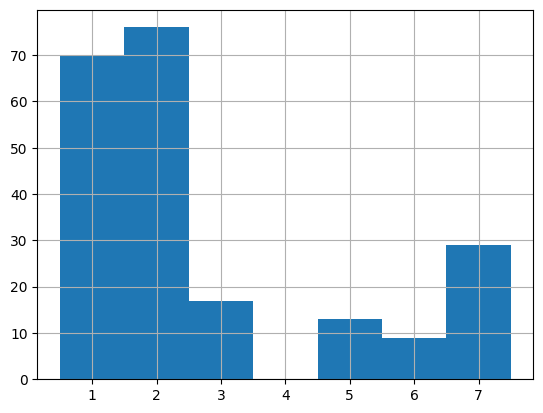

In [ ]:
data['Type'].hist(bins=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])

In [ ]:
data[data['Type']==4]

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type


## Step 5: Normalize Data [2 points]

Use `StandardScaler` from `Scikit-learn` to normalize all the feature columns (but exclude the label).
*   Store the normalized features in a DataFrame named `data_n_df`.
*   Make sure that all the original column names are preserved. ✅

In [ ]:
from sklearn.preprocessing import StandardScaler
### BEGIN SOLUTION

scaler = StandardScaler()
X = data.drop(columns=["Type"])
X_scaled = scaler.fit_transform(X)


data_n_df = pd.DataFrame(X_scaled, columns=X.columns)



### END SOLUTION

In [ ]:
#if you did the normalization correct, the follwoing command should print True
round(data_n_df['RI'].mean())+round(data_n_df['K'].mean())==0

True

## Step 6: Data Split [2 points]

Use  `train_test_split` from Scikit-learn and split the Features and Label(Y) to **70%** training subset and **30%** test subset. Use the variable names as shown below.

<font color=red>You **must** use `random_state=10` to get the result needed.</font>

In [ ]:
from sklearn.model_selection import train_test_split
### BEGIN SOLUTION
X = data_n_df
Y = data["Type"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=10,
    )



### END SOLUTION

<Axes: >

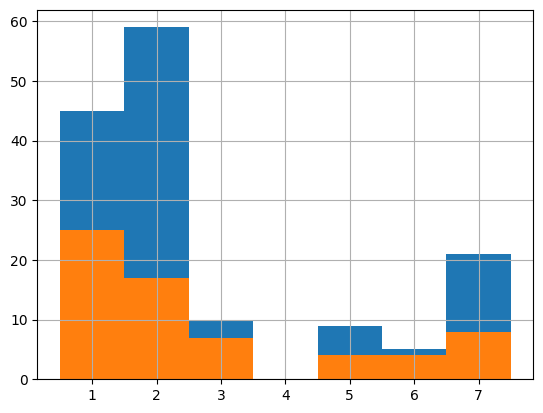

In [ ]:
#Review the following histograms and see how data is split.
Y_train.hist(bins=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])
Y_test.hist(bins=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5])

## Step 7: KNN [4 points]

Train KNN for K=2,3,4,5

*   Store the accuracy of the 4 models in a list named `accuracy_list`  
*   Store the f1-score of the 4 models in a list named `f1_score_list`

When your code finishes, Each list should have 4 numbers in this order: the first number for the 2NN Model, the second number is for the 3NN Model,...

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,f1_score
### BEGIN SOLUTION

accuracy_list = []
f1_score_list = []

for k in [2, 3, 4, 5]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred, average='weighted')

    accuracy_list.append(acc)
    f1_score_list.append(f1)





print (accuracy_list, f1_score_list)
### END SOLUTION

[0.5384615384615384, 0.5076923076923077, 0.5384615384615384, 0.5230769230769231] [0.4957185864068455, 0.4846153846153846, 0.5156885667523966, 0.50416884702599]


Based on the plot, we can decide what to use for K in KNeighborsClassifier.

Text(0.5, 1.0, 'Evaluation metrics vs. K')

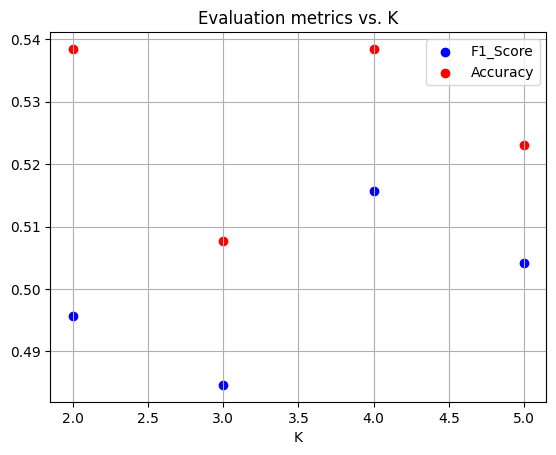

In [ ]:
#If you wrote the code correctly, running the following code, should create a plot of accuracy and f1-score of different models compared agains each other.
import matplotlib.pyplot as plt
plt.scatter(range(2,6),f1_score_list,label='F1_Score',color='blue')
plt.scatter(range(2,6),accuracy_list,label='Accuracy',color='red')
plt.xlabel('K')
plt.legend()
plt.grid()
plt.title('Evaluation metrics vs. K')

##Step 8: KNN- Best [1 point]

Useing the graph in the previous step, decide on the best K and train the model using the selected K and store test data predictions in a variable named `Y_testing_predicted`

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
### BEGIN SOLUTION




model = KNeighborsClassifier(n_neighbors=4)
model.fit(X_train, Y_train)

Y_testing_predicted = model.predict(X_test)





### END SOLUTION

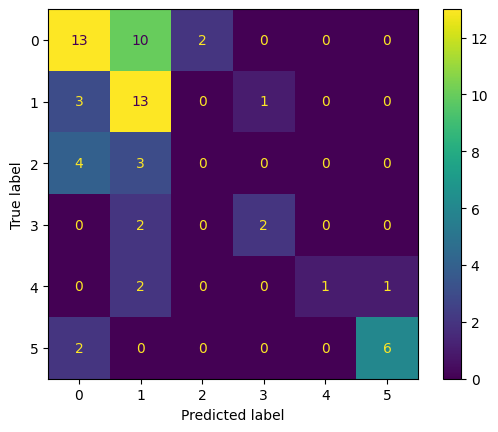

In [ ]:
#Run the following commands to get the Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix(Y_test,Y_testing_predicted))
disp.plot()


## Step 9: Logistic Regression - Grid Search [3 points]

Train Logistic Regression for all the combination of param_cases given below using GridSearchCV

In [ ]:
param_cases={
    'class_weight':['balanced'],
    'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter' : [25, 50]
}

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
### BEGIN SOLUTION



Model_G = LogisticRegression()
Model_Grid = GridSearchCV(
    Model_G,
    param_grid=param_cases,
    cv=5,
    scoring="accuracy"
)
Model_Grid.fit(X_train, Y_train)

Model_Best = Model_Grid

### END SOLUTION

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
#Running this command should give you the model parameters which resulted in the best accuracy_score
Model_Best.best_estimator_

LogisticRegression(class_weight='balanced', max_iter=25, solver='liblinear')

In [ ]:
#Running this command should give you a nice tablecomparing all models.

pd.concat([pd.DataFrame(Model_Best.cv_results_["params"]),pd.DataFrame(Model_Best.cv_results_["mean_test_score"], columns=["Accuracy"])],axis=1)


,class_weight,max_iter,solver,Accuracy
0,balanced,25,newton-cg,0.591264
1,balanced,25,lbfgs,0.591264
2,balanced,25,liblinear,0.611034
3,balanced,25,sag,0.584368
4,balanced,25,saga,0.584138
5,balanced,50,newton-cg,0.591264
6,balanced,50,lbfgs,0.591264
7,balanced,50,liblinear,0.611034
8,balanced,50,sag,0.591264
9,balanced,50,saga,0.577471


## Step 10: Logistic Regression - Best

Running the following command should give you a confusion matrix of the best logistic regression model!

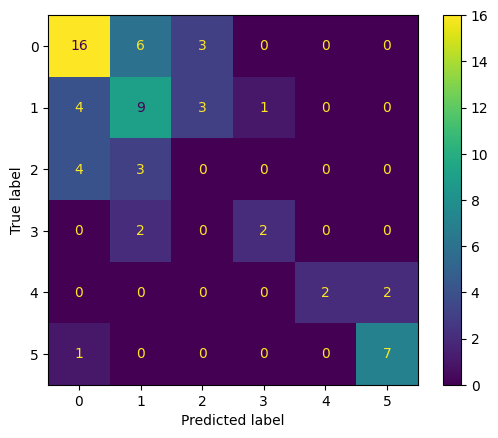

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix(Y_test,Model_Best.best_estimator_.predict(X_test)))
disp.plot()
